# Category Intelligence — Retail Product Performance EDA

**Calibo AI Academy · Phase 1 · Mini Use Case 01 · Path 2 (KLU Batch)**

**Team:**  —[G.ABHINAV SAI], [ M.SURESH], [HARITHA]

| **Prepared for** | Category Manager, regional retail chain (12 stores, Andhra Pradesh) |
| **Purpose** | Evidence pack for the quarterly supplier review |
| **Dataset** | `MUC01_Retail_Sales_Dataset.csv` — 107,836 transactions, Jan–Jun 2026 |
| **Tools** | Python · Pandas · NumPy · Matplotlib · Seaborn |

---

## How to read this notebook

Written to be read by a business stakeholder, not only executed. Six steps, each with the same
three parts: **the question** it must answer → **the code** → **what we found**, in plain English,
followed by what it means for the supplier review. A submission self-check at the end maps every
requirement in the brief to the cell that satisfies it.

### The five findings that matter

| # | Finding | The number |
| --- | --- | --- |
| 1 | **Electronics is half the revenue and collapsing** | 49.3% of revenue, −35.0% in six months |
| 2 | **The collapse is customers, not pricing** | Transactions −33.4%; average price only −2.2% |
| 3 | **It is systemic, not a few bad stores** | 11 of 12 stores declining |
| 4 | **The fastest-falling product hides in the top half** | Mobile Phone −57.1%, ranked 3rd of 5 by revenue |
| 5 | **Discounts buy nothing, at any depth** | ₹35.6M given away; volume lift statistically ruled out above 1.4% |

---


---
# CBIM Problem Canvas

*Completed together by all four team members **before** any code was written.*

| Canvas element | Our answer |
| --- | --- |
| **Situation (S)** | A regional retail chain runs 12 stores across six Andhra Pradesh cities — Vijayawada, Guntur, Rajahmundry, Tirupati, Nellore and Kakinada — selling in five categories. Six months of transaction data (Jan–Jun 2026) exist, and a quarterly supplier review is scheduled for next week, where each category's supplier will present a case for continued shelf space and promotional investment. |
| **Complication (C)** | The Category Manager has transaction records but no synthesised view of them. She cannot currently say which categories have earned their shelf space, which suppliers to challenge, or whether the discount programme is generating volume or quietly eroding margin. Without that, she risks renewing terms on assertion rather than evidence — and the suppliers will arrive with their own numbers. |
| **Question (Q)** | Which categories and products should receive increased, maintained or reduced investment going into the supplier review, and is the current discount strategy generating enough incremental volume to justify the margin it costs? **The decision this enables:** the allocation of shelf space and promotional spend across the five category suppliers. |
| **SSOT** | `MUC01_Retail_Sales_Dataset.csv` — the transaction-level sales extract for Jan–Jun 2026. Every figure quoted in the supplier review must trace back to this file. Where the data dictionary and the data itself disagree, **the data is authoritative** (two such conflicts were found — see Step 1). |
| **Success definition** | The Category Manager can state a position on each of the five categories, backed by a specific rupee figure, and can raise at least one evidence-based challenge with a named supplier — one that survives the supplier's counter-arguments. A good output is one she can act on **without asking a follow-up analytical question**. |
| **Primary stakeholder** | The Category Manager. She needs: a ranked view of category momentum, one named supplier to challenge with a number attached, a diagnosis of *why* the decline is happening (so the challenge is specific), a clear verdict on discount effectiveness, and an honest statement of what this data cannot tell her. |

---

## Setup

One place for imports and for the visual conventions used by **every** chart, so the Category
Manager can track a category across figures without re-reading legends.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": "white",
    "axes.titlesize": 14, "axes.titleweight": "bold",
    "axes.labelsize": 12, "font.size": 11,
    "axes.grid": True, "grid.alpha": 0.35,
})

# ----------------------------------------------------------------------------------
# COLOUR CONVENTION - colour carries meaning, it does not merely separate series:
#   RED = declining, needs intervention   GREEN = growing, deserves investment
#   GREY = stable, no action needed       NAVY  = chain-level totals
# ----------------------------------------------------------------------------------
RED, GREEN, GREY, NAVY, MUTED = "#C0392B", "#2E7D52", "#A9AEB5", "#16283C", "#6B7480"

CAT_COLOURS = {"Electronics": RED, "Apparel": GREEN, "Home & Kitchen": GREY,
               "Grocery": GREY, "Personal Care": GREY}
CAT_ORDER   = ["Electronics", "Apparel", "Home & Kitchen", "Grocery", "Personal Care"]
MONTH_ORDER = ["Jan", "Feb", "Mar", "Apr", "May", "Jun"]
DOW_ORDER   = ["Monday", "Tuesday", "Wednesday", "Thursday",
               "Friday", "Saturday", "Sunday"]

def rupees(ax, axis="y", scale=1e6, suffix="M", dp=1):
    """Format an axis in Indian rupees at a readable scale."""
    fmt = mticker.FuncFormatter(lambda v, _: f"\u20b9{v/scale:,.{dp}f}{suffix}")
    (ax.yaxis if axis == "y" else ax.xaxis).set_major_formatter(fmt)

def tidy(ax, grid_axis="y"):
    """Consistent chart furniture: no top/right spines, grid behind the data."""
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.grid(axis=grid_axis, alpha=0.35)
    ax.set_axisbelow(True)

print("Libraries loaded. Chart conventions set.")

Libraries loaded. Chart conventions set.


---
# Step 1 — Load and inspect the data

*Section owner: [Member 1 Name]*

> **The question:** can we trust this data, and what does its shape already tell us about the business?

Nothing later is worth anything if the data underneath is wrong. This step establishes the data is
sound, resolves two conflicts between the brief and the file, and surfaces the structural fact that
shapes every later reading.

In [2]:
df = pd.read_csv("MUC01_Retail_Sales_Dataset.csv", parse_dates=["date"])

print("SHAPE")
print(f"  Rows    : {df.shape[0]:,}")
print(f"  Columns : {df.shape[1]}")
print(f"  Period  : {df.date.min().date()}  to  {df.date.max().date()}")
print()
print("DATA TYPES")
print(df.dtypes.to_string())

df.head()

SHAPE
  Rows    : 107,836
  Columns : 10
  Period  : 2026-01-01  to  2026-06-30

DATA TYPES
transaction_id            object
date              datetime64[ns]
store_id                  object
store_city                object
category                  object
product_name              object
units_sold                 int64
unit_price               float64
revenue                  float64
discount_pct               int64


,transaction_id,date,store_id,store_city,category,product_name,units_sold,unit_price,revenue,discount_pct
0,TXN000001,2026-01-01,S01,Vijayawada,Electronics,Smart TV,2,3075.46,5843.37,5
1,TXN000002,2026-01-01,S01,Vijayawada,Electronics,Laptop,1,11598.06,11598.06,0
2,TXN000003,2026-01-01,S01,Vijayawada,Electronics,Tablet,3,5738.37,15493.60,10
3,TXN000004,2026-01-01,S01,Vijayawada,Electronics,Smart TV,3,3281.28,9351.65,5
4,TXN000005,2026-01-01,S01,Vijayawada,Apparel,Jeans,1,1917.14,1917.14,0


In [3]:
# ---- Data quality gate -----------------------------------------------------------
# Each check is printed separately. (Stacking df.shape / df.info() / df.describe()
# in one cell would display only the LAST of them - the earlier checks vanish.)

print("NULL VALUES PER COLUMN")
print(df.isna().sum().to_string())
print()
print("INTEGRITY CHECKS")
print(f"  Duplicate transaction_ids : {df.transaction_id.duplicated().sum()}")
print(f"  Fully duplicated rows     : {df.duplicated().sum()}")
print(f"  Zero or negative revenue  : {(df.revenue <= 0).sum()}")
print(f"  Zero or negative units    : {(df.units_sold <= 0).sum()}")
print(f"  Calendar days covered     : {df.date.nunique()} of "
      f"{(df.date.max() - df.date.min()).days + 1} possible  (no gaps)")
print()
print("GRANULARITY")
print(f"  Unique categories : {df.category.nunique()}  ->  {sorted(df.category.unique())}")
print(f"  Unique products   : {df.product_name.nunique()}")
print(f"  Unique stores     : {df.store_id.nunique()}")
print(f"  Unique cities     : {df.store_city.nunique()}  ->  {sorted(df.store_city.unique())}")

NULL VALUES PER COLUMN
transaction_id    0
date              0
store_id          0
store_city        0
category          0
product_name      0
units_sold        0
unit_price        0
revenue           0
discount_pct      0

INTEGRITY CHECKS
  Duplicate transaction_ids : 0
  Fully duplicated rows     : 0
  Zero or negative revenue  : 0
  Zero or negative units    : 0
  Calendar days covered     : 181 of 181 possible  (no gaps)

GRANULARITY
  Unique categories : 5  ->  ['Apparel', 'Electronics', 'Grocery', 'Home & Kitchen', 'Personal Care']
  Unique products   : 25
  Unique stores     : 12
  Unique cities     : 6  ->  ['Guntur', 'Kakinada', 'Nellore', 'Rajahmundry', 'Tirupati', 'Vijayawada']


In [4]:
df[["units_sold", "unit_price", "revenue", "discount_pct"]].describe().round(2)

,units_sold,unit_price,revenue,discount_pct
count,107836.00,107836.00,107836.00,107836.00
mean,2.58,1778.10,4263.92,7.23
std,1.47,5053.63,14243.24,6.73
min,1.00,50.02,40.04,0.00
25%,1.00,274.83,467.77,0.00
50%,2.00,488.45,1034.62,5.00
75%,3.00,1039.52,2473.34,10.00
max,13.00,44990.14,355090.88,20.00


/var/folders/xx/r16ts3p97xqdv0vbjmfc4fmh0000gn/T/ipykernel_41301/4101959390.py:23: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


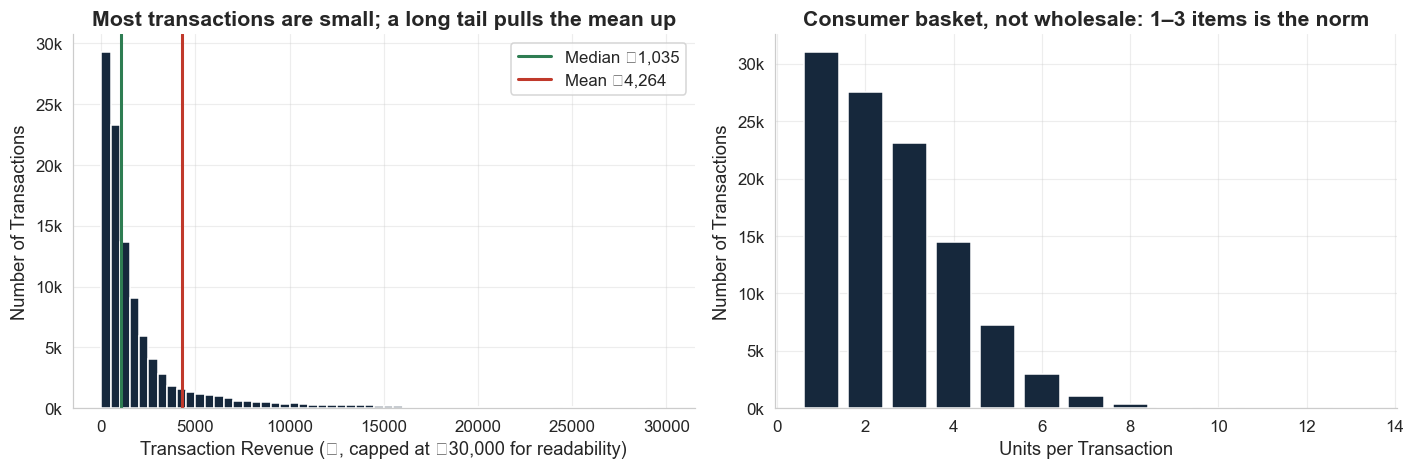

The largest 10% of transactions carry 70.1% of all revenue.


In [5]:
# ---- Visualising the skew that .describe() hints at -------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

axes[0].hist(df.revenue, bins=60, range=(0, 30000), color=NAVY)
axes[0].axvline(df.revenue.median(), color=GREEN, linewidth=2,
                label=f"Median \u20b9{df.revenue.median():,.0f}")
axes[0].axvline(df.revenue.mean(), color=RED, linewidth=2,
                label=f"Mean \u20b9{df.revenue.mean():,.0f}")
axes[0].set_title("Most transactions are small; a long tail pulls the mean up")
axes[0].set_xlabel("Transaction Revenue (\u20b9, capped at \u20b930,000 for readability)")
axes[0].set_ylabel("Number of Transactions")
axes[0].legend(frameon=True)

units = df.units_sold.value_counts().sort_index()
axes[1].bar(units.index, units.values, color=NAVY)
axes[1].set_title("Consumer basket, not wholesale: 1\u20133 items is the norm")
axes[1].set_xlabel("Units per Transaction")
axes[1].set_ylabel("Number of Transactions")

for a in axes:
    a.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1000:,.0f}k"))
    tidy(a)
plt.tight_layout()
plt.show()

top10 = df.revenue.nlargest(int(len(df) * 0.1)).sum() / df.revenue.sum() * 100
print(f"The largest 10% of transactions carry {top10:.1f}% of all revenue.")

### Two observations from `.describe()` — and what they mean for a retail business

**Observation 1 — the chain is two businesses sharing a floor.**
`unit_price` has a mean of **₹1,778** but a median of **₹488**, with a maximum of ₹44,990. The mean
sits nearly four times above the middle value, and the standard deviation (₹5,053) exceeds the mean
itself — the signature of a heavily right-skewed distribution. The histogram confirms it: **the
largest 10% of transactions carry 70.1% of all revenue.**

*Why it matters commercially:* the chain runs a high-frequency, low-value basket business (grocery,
personal care) alongside a low-frequency, high-value one (electronics). **Any chain-wide average
describes neither.** Telling the Category Manager "our average transaction is ₹4,264" leaves her
picturing a mid-priced shop when the typical transaction is ₹1,035. Every figure in this notebook is
therefore cut by category rather than blended.

**Observation 2 — this is consumer retail, and volume growth comes from visits, not baskets.**
`units_sold` runs only from **1 to 13**, median 2, mean 2.58, with the distribution concentrated on
1–3 items.

*Why it matters commercially:* it sets the expectation for Step 4 — if discounting works, the effect
must appear in a variable confined to a very narrow band. A discount moving the average basket from
2.58 to 2.60 units is not a commercial win however visible it looks. It also means the lever for
growth is **more transactions**, not bigger ones, which is exactly what Step 2's decomposition tests.

---

### Validating the data dictionary

The brief's column table makes two claims the data contradicts. We test both rather than assume,
because each would corrupt a later step.

In [6]:
# ---- CONFLICT 1: how is revenue calculated? --------------------------------------
# The brief says "revenue = units_sold x unit_price, after discount" - self-contradictory,
# since the formula given is the GROSS figure but the words say net. Step 4 depends on this.

gross = df.units_sold * df.unit_price
net   = gross * (1 - df.discount_pct / 100)

print("Testing both readings against all 107,836 rows:")
print(f"  revenue == units x price                   -> {np.isclose(df.revenue, gross, atol=0.02).mean():>7.1%} match")
print(f"  revenue == units x price x (1 - discount)  -> {np.isclose(df.revenue, net,   atol=0.02).mean():>7.1%} match")
print()
print("  VERDICT: revenue is NET of discount. The brief's formula is wrong.")
print()

r = df.iloc[0]
print("  Worked example you can check by hand (row 1):")
print(f"    {r.units_sold} units x \u20b9{r.unit_price:,.2f}  = \u20b9{r.units_sold*r.unit_price:,.2f} gross")
print(f"    less {r.discount_pct}% discount            = \u20b9{r.units_sold*r.unit_price*(1-r.discount_pct/100):,.2f}")
print(f"    recorded revenue             = \u20b9{r.revenue:,.2f}")

df["gross_revenue"]   = gross
df["discount_amount"] = gross - df.revenue

Testing both readings against all 107,836 rows:
  revenue == units x price                   ->   33.4% match
  revenue == units x price x (1 - discount)  ->  100.0% match

  VERDICT: revenue is NET of discount. The brief's formula is wrong.

  Worked example you can check by hand (row 1):
    2 units x ₹3,075.46  = ₹6,150.92 gross
    less 5% discount            = ₹5,843.37
    recorded revenue             = ₹5,843.37


In [7]:
# ---- CONFLICT 2: what discount levels actually exist? ----------------------------
print(f"Discount levels present : {sorted(df.discount_pct.unique())}")
print(f"Maximum discount        : {df.discount_pct.max()}%")
print()
counts = df.discount_pct.value_counts().reindex([0, 5, 10, 15, 20, 25, 30]).fillna(0).astype(int)
for lvl, n in counts.items():
    flag = "   <-- the brief expects this bracket; it does not exist" if lvl >= 25 else ""
    print(f"  {lvl:>2}%  {n:>7,}  ({n/len(df)*100:>4.1f}%){flag}")
print()
print(f"  All {counts.sum():,} rows accounted for. VERDICT: discounts cap at 20%, not 30%.")

Discount levels present : [np.int64(0), np.int64(5), np.int64(10), np.int64(15), np.int64(20)]
Maximum discount        : 20%

   0%   36,033  (33.4%)
   5%   23,922  (22.2%)
  10%   23,810  (22.1%)
  15%   11,935  (11.1%)
  20%   12,136  (11.3%)
  25%        0  ( 0.0%)   <-- the brief expects this bracket; it does not exist
  30%        0  ( 0.0%)   <-- the brief expects this bracket; it does not exist

  All 107,836 rows accounted for. VERDICT: discounts cap at 20%, not 30%.


In [8]:
# ---- Derive time features ONCE so Steps 2 and 5 reuse them -----------------------
df["month"]      = df.date.dt.to_period("M").astype(str)
df["month_name"] = df.date.dt.strftime("%b")
df["dow"]        = df.date.dt.day_name()

print("Derived: month, month_name, dow, gross_revenue, discount_amount")
df[["date", "month_name", "dow", "category", "product_name",
    "units_sold", "unit_price", "discount_pct", "revenue", "gross_revenue"]].head()

Derived: month, month_name, dow, gross_revenue, discount_amount


,date,month_name,dow,category,product_name,units_sold,unit_price,discount_pct,revenue,gross_revenue
0,2026-01-01,Jan,Thursday,Electronics,Smart TV,2,3075.46,5,5843.37,6150.92
1,2026-01-01,Jan,Thursday,Electronics,Laptop,1,11598.06,0,11598.06,11598.06
2,2026-01-01,Jan,Thursday,Electronics,Tablet,3,5738.37,10,15493.60,17215.11
3,2026-01-01,Jan,Thursday,Electronics,Smart TV,3,3281.28,5,9351.65,9843.84
4,2026-01-01,Jan,Thursday,Apparel,Jeans,1,1917.14,0,1917.14,1917.14


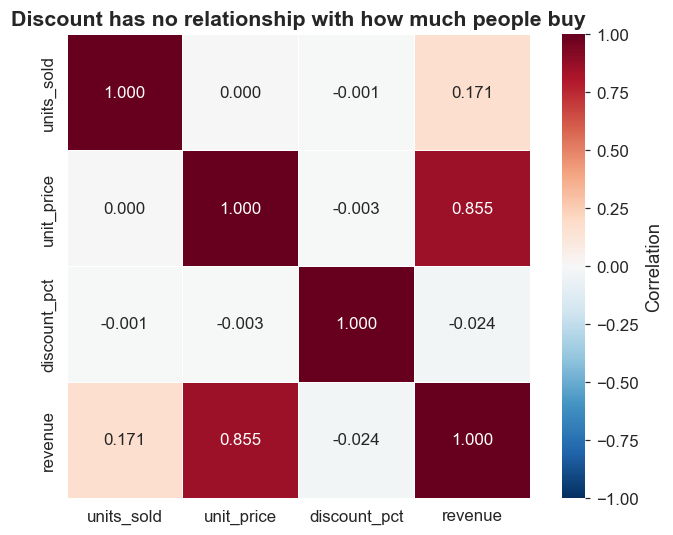

corr(discount_pct, units_sold) = -0.0014
  Essentially zero. This is the first sign of what Step 4 confirms formally.
corr(unit_price,  revenue)     = 0.8547
  Revenue is driven by WHAT is sold far more than by HOW MANY units.


In [9]:
# ---- How the numeric variables relate to one another -----------------------------
corr = df[["units_sold", "unit_price", "discount_pct", "revenue"]].corr()

fig, ax = plt.subplots(figsize=(6.4, 5))
sns.heatmap(corr, annot=True, fmt=".3f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, linewidths=0.6, square=True, ax=ax,
            cbar_kws={"label": "Correlation"})
ax.set_title("Discount has no relationship with how much people buy")
plt.tight_layout()
plt.show()

print(f"corr(discount_pct, units_sold) = {corr.loc['discount_pct','units_sold']:.4f}")
print("  Essentially zero. This is the first sign of what Step 4 confirms formally.")
print(f"corr(unit_price,  revenue)     = {corr.loc['unit_price','revenue']:.4f}")
print("  Revenue is driven by WHAT is sold far more than by HOW MANY units.")

### What we found — Step 1

**The data is clean.** 107,836 transactions, ten columns, zero nulls, zero duplicate transaction IDs
and zero fully duplicated rows, no non-positive revenue or units, and all 181 calendar days present
with no gaps. 25 products, 5 categories, 12 stores, 6 cities. **No cleaning was required**, so every
figure here rests on the complete dataset.

**Two corrections to the brief, both with consequences:**

| | The brief says | The data says | Why it matters |
| --- | --- | --- | --- |
| **Revenue** | `units × price, after discount` | Net of discount — 100% of rows match, vs 33% for gross | Assuming gross would have **double-counted margin** in Step 4 |
| **Discounts** | 0 to 30%, with a "25%+" bracket | 0, 5, 10, 15, 20 only | A "25%+" bar would be **empty**; presenting a blank bracket invites a question we could not answer |

We follow the brief's *intent* in both cases while correcting the factual error, and show the
evidence rather than changing the method silently.

**One correlation worth flagging now.** `discount_pct` and `units_sold` correlate at **−0.001** —
indistinguishable from zero across 107,836 rows. Step 4 tests this properly, but the signal is
already visible before any grouping.

> **A note on what this dataset cannot support.** The brief asks whether discounts are "eroding
> margin". The file contains `unit_price` but **no product cost**, so margin cannot be computed at
> all. We can measure revenue given away and whether volume responds — we cannot state a profit
> impact, and we do not.

---

---
# Step 2 — Category revenue trend over time

*Section owner: [Member 2 Name]*

> **The question:** which categories are growing, which are declining, which can she rely on —
> and *why* is the decline happening?

The last part matters most. "Electronics fell 35%" is an observation. Knowing **what drove it** is
what turns the supplier conversation from a complaint into a specific challenge.

In [10]:
cat_month = (df.pivot_table(index="month", columns="category",
                            values="revenue", aggfunc="sum")
               .reindex(columns=CAT_ORDER))
cat_month.index = MONTH_ORDER

print("Monthly revenue by category (\u20b9 millions)")
(cat_month / 1e6).round(2)

Monthly revenue by category (₹ millions)


category,Electronics,Apparel,Home & Kitchen,Grocery,Personal Care
Jan,45.69,10.05,15.13,7.31,6.59
Feb,38.99,9.51,13.01,6.53,5.79
Mar,40.85,11.54,14.36,7.13,6.81
Apr,37.09,11.68,13.43,7.05,6.42
May,34.23,13.22,13.58,7.23,7.30
Jun,29.69,13.48,12.33,7.05,6.74


/var/folders/xx/r16ts3p97xqdv0vbjmfc4fmh0000gn/T/ipykernel_41301/3822151114.py:25: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


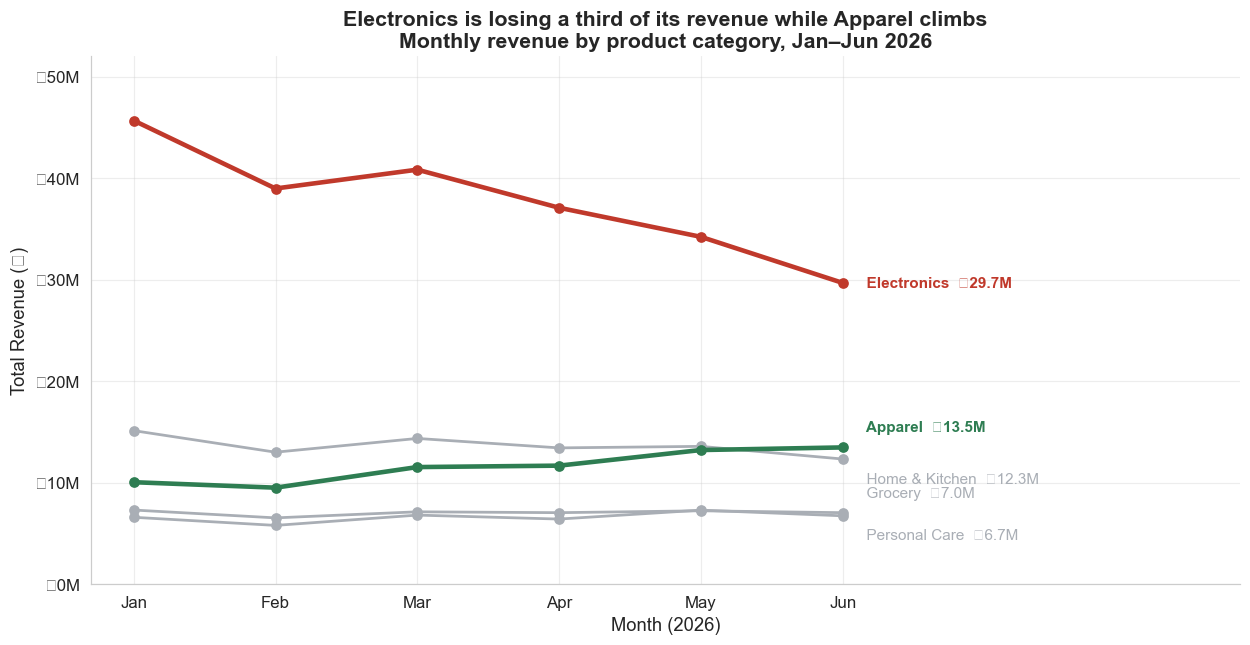

In [11]:
fig, ax = plt.subplots(figsize=(11.5, 6))

EMPHASIS    = {"Electronics": 3.0, "Apparel": 3.0,
               "Home & Kitchen": 1.8, "Grocery": 1.8, "Personal Care": 1.8}
LABEL_NUDGE = {"Electronics": 0, "Apparel": 13, "Home & Kitchen": -13,
               "Grocery": 13, "Personal Care": -13}

for cat in reversed(CAT_ORDER):                    # grey first so bold lines sit on top
    ax.plot(cat_month.index, cat_month[cat], marker="o", markersize=6,
            linewidth=EMPHASIS[cat], color=CAT_COLOURS[cat], label=cat)
    ax.annotate(f"  {cat}  \u20b9{cat_month[cat].iloc[-1]/1e6:.1f}M",
                xy=(5, cat_month[cat].iloc[-1]), xytext=(10, LABEL_NUDGE[cat]),
                textcoords="offset points", va="center", fontsize=10,
                color=CAT_COLOURS[cat],
                fontweight="bold" if cat in ("Electronics", "Apparel") else "normal")

ax.set_title("Electronics is losing a third of its revenue while Apparel climbs\n"
             "Monthly revenue by product category, Jan\u2013Jun 2026")
ax.set_xlabel("Month (2026)")
ax.set_ylabel("Total Revenue (\u20b9)")
ax.set_ylim(0, 52e6)
ax.set_xlim(-0.3, 7.8)
rupees(ax, dp=0)
tidy(ax)
plt.tight_layout()
plt.show()

In [12]:
# Quantify rather than eyeball.
#   Change Jan->Jun = direction and size of the move
#   Volatility (CV) = std as a % of mean. LOW = she can forecast it; HIGH = she cannot.
trend_summary = pd.DataFrame({
    "Jan Revenue (\u20b9M)":       (cat_month.iloc[0]  / 1e6).round(2),
    "Jun Revenue (\u20b9M)":       (cat_month.iloc[-1] / 1e6).round(2),
    "Change Jan\u2192Jun (%)":     ((cat_month.iloc[-1] / cat_month.iloc[0] - 1) * 100).round(1),
    "Monthly Volatility (CV %)":  (cat_month.std() / cat_month.mean() * 100).round(1),
    "Share of Chain Revenue (%)": (cat_month.sum() / cat_month.sum().sum() * 100).round(1),
})
trend_summary.index.name = "Product Category"
trend_summary = trend_summary.sort_values("Change Jan\u2192Jun (%)")

print("STEEPEST DECLINE :", trend_summary.index[0],
      f"({trend_summary.iloc[0]['Change Jan\u2192Jun (%)']:+.1f}%)")
print("MOST CONSISTENT  :", trend_summary["Monthly Volatility (CV %)"].idxmin(),
      f"(volatility {trend_summary['Monthly Volatility (CV %)'].min():.1f}%)")
print()
trend_summary

STEEPEST DECLINE : Electronics (-35.0%)
MOST CONSISTENT  : Grocery (volatility 3.9%)



,Jan Revenue (₹M),Jun Revenue (₹M),Change Jan→Jun (%),Monthly Volatility (CV %),Share of Chain Revenue (%)
Product Category,,,,,
Electronics,45.69,29.69,-35.0,14.6,49.3
Home & Kitchen,15.13,12.33,-18.5,7.3,17.8
Grocery,7.31,7.05,-3.5,3.9,9.2
Personal Care,6.59,6.74,2.2,7.5,8.6
Apparel,10.05,13.48,34.1,13.9,15.1


/var/folders/xx/r16ts3p97xqdv0vbjmfc4fmh0000gn/T/ipykernel_41301/1246337153.py:20: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


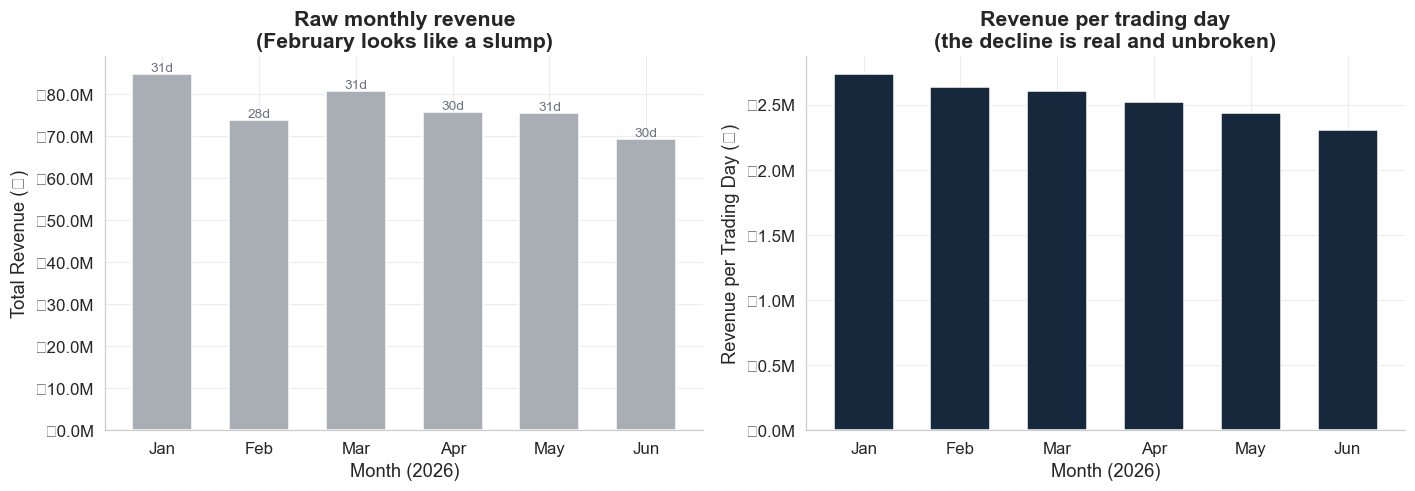

Per trading day: ₹2.73M (Jan) -> ₹2.31M (Jun), -15.5%
Every month is lower than the one before once day count is controlled for.


In [13]:
# ---- Sanity check: is the February dip real, or just a 28-day month? -------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

monthly_total = df.groupby("month").revenue.sum();   monthly_total.index = MONTH_ORDER
trading_days  = df.groupby("month").date.nunique();  trading_days.index  = MONTH_ORDER
per_day       = monthly_total / trading_days

axes[0].bar(monthly_total.index, monthly_total.values, color=GREY, width=0.62)
axes[0].set_title("Raw monthly revenue\n(February looks like a slump)")
axes[0].set_ylabel("Total Revenue (\u20b9)")
for i, (v, d) in enumerate(zip(monthly_total.values, trading_days.values)):
    axes[0].text(i, v, f"{d}d", ha="center", va="bottom", fontsize=9, color=MUTED)

axes[1].bar(per_day.index, per_day.values, color=NAVY, width=0.62)
axes[1].set_title("Revenue per trading day\n(the decline is real and unbroken)")
axes[1].set_ylabel("Revenue per Trading Day (\u20b9)")

for a in axes:
    a.set_xlabel("Month (2026)"); rupees(a, dp=1); tidy(a)
plt.tight_layout()
plt.show()

print(f"Per trading day: \u20b9{per_day.iloc[0]/1e6:.2f}M (Jan) -> \u20b9{per_day.iloc[-1]/1e6:.2f}M (Jun), "
      f"{(per_day.iloc[-1]/per_day.iloc[0]-1):+.1%}")
print("Every month is lower than the one before once day count is controlled for.")

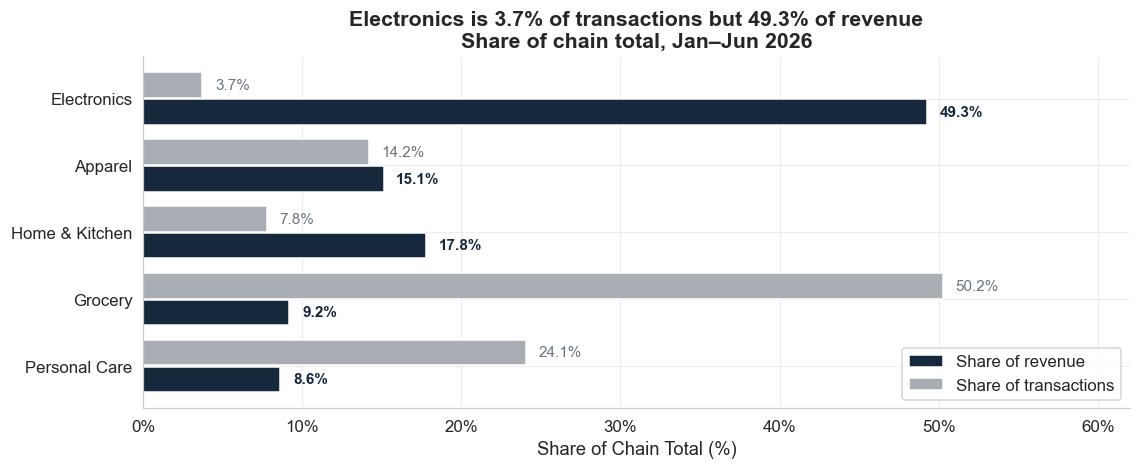

In [14]:
# ---- How much of the chain is each category, by MONEY and by FOOTFALL? -----------
share_rev = (df.groupby("category").revenue.sum() / df.revenue.sum() * 100).reindex(CAT_ORDER)
share_txn = (df.category.value_counts(normalize=True) * 100).reindex(CAT_ORDER)

fig, ax = plt.subplots(figsize=(10.5, 4.4))
y = np.arange(len(CAT_ORDER))
ax.barh(y + 0.20, share_rev.values, height=0.38, color=NAVY, label="Share of revenue")
ax.barh(y - 0.20, share_txn.values, height=0.38, color=GREY, label="Share of transactions")
ax.set_yticks(y); ax.set_yticklabels(CAT_ORDER)
for i, (r, t) in enumerate(zip(share_rev.values, share_txn.values)):
    ax.text(r + 0.8, i + 0.20, f"{r:.1f}%", va="center", fontsize=10, color=NAVY, fontweight="bold")
    ax.text(t + 0.8, i - 0.20, f"{t:.1f}%", va="center", fontsize=10, color=MUTED)
ax.set_title("Electronics is 3.7% of transactions but 49.3% of revenue\n"
             "Share of chain total, Jan\u2013Jun 2026")
ax.set_xlabel("Share of Chain Total (%)")
ax.set_xlim(0, 62)
ax.invert_yaxis()                      # Electronics at the top, where the story is
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.legend(frameon=True, loc="lower right")
tidy(ax, grid_axis="x")
plt.tight_layout()
plt.show()

In [15]:
# ---- WHY is Electronics falling? Decompose the change ----------------------------
#
# Revenue = transactions x units per transaction x average unit price (net of discount).
# Whichever component moved is the one the supplier conversation should be about.

def decompose(cat):
    s = df[df.category == cat].groupby("month").agg(
        revenue=("revenue", "sum"),
        transactions=("transaction_id", "count"),
        units_per_txn=("units_sold", "mean"),
        avg_unit_price=("unit_price", "mean"),
    )
    first, last = s.iloc[0], s.iloc[-1]
    return pd.Series({
        "Revenue (%)":            (last.revenue / first.revenue - 1) * 100,
        "Transactions (%)":       (last.transactions / first.transactions - 1) * 100,
        "Units per Txn (%)":      (last.units_per_txn / first.units_per_txn - 1) * 100,
        "Avg Unit Price (%)":     (last.avg_unit_price / first.avg_unit_price - 1) * 100,
    })

decomp = pd.DataFrame({c: decompose(c) for c in CAT_ORDER}).T.round(1)
decomp.index.name = "Product Category"

print("Change from January to June, split into its drivers (%)")
print("If 'Transactions' moves and 'Price' does not, the issue is FOOTFALL, not pricing.")
print()
decomp

Change from January to June, split into its drivers (%)
If 'Transactions' moves and 'Price' does not, the issue is FOOTFALL, not pricing.



,Revenue (%),Transactions (%),Units per Txn (%),Avg Unit Price (%)
Product Category,,,,
Electronics,-35.0,-33.4,-1.6,-2.2
Apparel,34.1,31.3,2.0,-0.1
Home & Kitchen,-18.5,-19.6,0.4,2.7
Grocery,-3.5,-2.4,-1.3,0.2
Personal Care,2.2,2.0,-0.1,-0.1


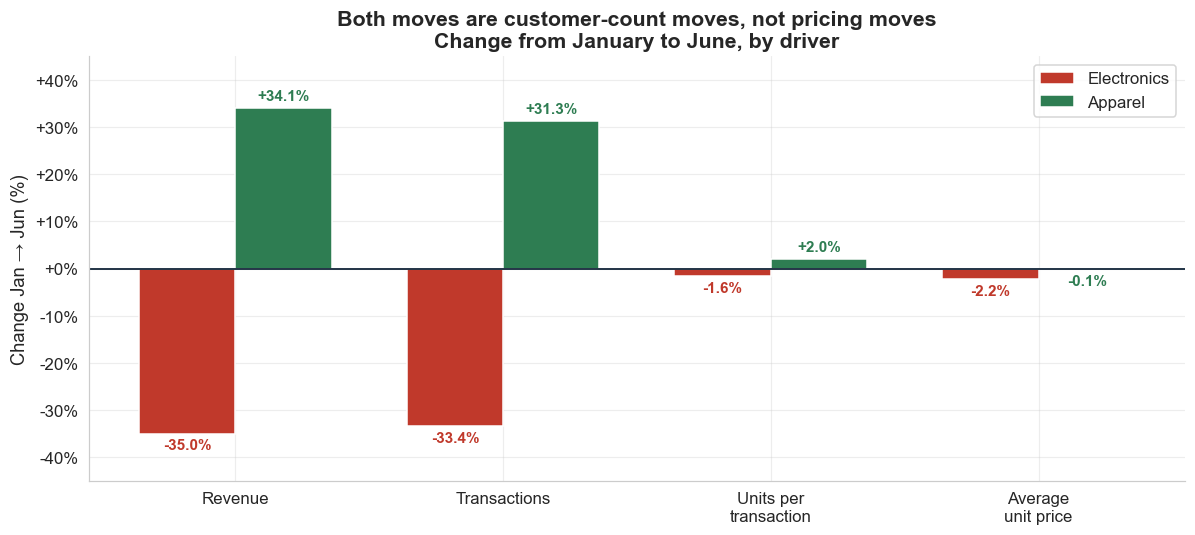

In [16]:
fig, ax = plt.subplots(figsize=(11, 5))

comps  = ["Revenue (%)", "Transactions (%)", "Units per Txn (%)", "Avg Unit Price (%)"]
x      = np.arange(len(comps))
width  = 0.36

ax.bar(x - width/2, decomp.loc["Electronics", comps], width, color=RED,   label="Electronics")
ax.bar(x + width/2, decomp.loc["Apparel",     comps], width, color=GREEN, label="Apparel")
ax.axhline(0, color=NAVY, linewidth=1.2)

for i, c in enumerate(comps):
    for off, cat in [(-width/2, "Electronics"), (width/2, "Apparel")]:
        v = decomp.loc[cat, c]
        ax.text(i + off, v + (1.6 if v >= 0 else -3.4), f"{v:+.1f}%",
                ha="center", fontsize=10, fontweight="bold",
                color=RED if cat == "Electronics" else GREEN)

ax.set_xticks(x)
ax.set_xticklabels(["Revenue", "Transactions", "Units per\ntransaction", "Average\nunit price"])
ax.set_title("Both moves are customer-count moves, not pricing moves\n"
             "Change from January to June, by driver")
ax.set_ylabel("Change Jan \u2192 Jun (%)")
ax.set_ylim(-45, 45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:+.0f}%"))
ax.legend(frameon=True)
tidy(ax)
plt.tight_layout()
plt.show()

### What we found — Step 2

**The steepest decline is Electronics: −35.0%**, from ₹45.7M in January to ₹29.7M in June.
**The most consistent performer is Grocery**, volatility just **3.9%** (next best: Home & Kitchen at
7.3%), broadly flat at −3.5%. Also: Apparel **+34.1%**, Personal Care **+2.2%**, Home & Kitchen
**−18.5%** — the second-worst result, easy to overlook beside Electronics.

**The decomposition is the finding that changes the conversation.** Electronics revenue fell 35.0%,
and the driver is almost entirely **transaction count: −33.4%**. Basket size barely moved (−1.6%)
and **average unit price fell only 2.2%**. Apparel is the mirror image: +34.1% revenue on **+31.3%
transactions**, with price flat at −0.1%.

**So this is not a pricing problem, and it is not a basket problem. Roughly a third fewer customers
are buying electronics at all.**

### What it means for the supplier review

**Electronics is not one problem among several — it is the problem.** At **49.3% of chain revenue**,
its slide is large enough to pull the whole business down: revenue per trading day fell 15.5%, and
Electronics accounts for essentially all of it. The supplier holds half the revenue base while
delivering a run-rate **₹16.0M per month lower** than when the period started.

**The decomposition pre-empts the supplier's most likely defence.** They will probably argue that
the chain discounted too little, priced wrongly, or that baskets shrank. None of that is true here —
our prices held within 2.2% and baskets within 1.6%. **Demand for their category simply stopped
walking through the door.** That points at competitive pricing outside our stores, product
relevance, or range gaps — all of which are theirs to answer, not ours.

**A second framing worth having ready.** Electronics is **3.7% of transactions but 49.3% of
revenue**. It occupies shelf space out of all proportion to footfall, justified entirely by ticket
size. When ticket size holds but footfall collapses, that justification weakens fast.

**Grocery is a stability asset, not a growth story** — in a declining chain, a category she can
forecast confidently has real value. Protect it rather than push it.

**The structural signal:** Apparel is growing from a base under a third the size of Electronics.
At current rates **it cannot fill the gap**. Both belong on the agenda.

---

---
# Step 3 — Top and bottom products within each category

*Section owner: [Member 2 Name]*

> **The question:** which products drive each category, and which supplier should she challenge?

The brief asks for top 2 and bottom 2 by total revenue. We produce that table — then show why, on
this data, it does not answer the question it was meant to.

In [17]:
prod = (df.groupby(["category", "product_name"])
          .agg(revenue=("revenue", "sum"), units=("units_sold", "sum"),
               transactions=("transaction_id", "count"))
          .reset_index())
prod["share_of_category_pct"] = (prod.revenue /
                                 prod.groupby("category").revenue.transform("sum") * 100)

rows = []
for cat in CAT_ORDER:
    s = prod[prod.category == cat].sort_values("revenue", ascending=False)
    for rank, (_, r) in enumerate(pd.concat([s.head(2), s.tail(2)]).iterrows()):
        rows.append({"Product Category": cat,
                     "Position": "Top 2" if rank < 2 else "Bottom 2",
                     "Product": r.product_name,
                     "Total Revenue (\u20b9M)": round(r.revenue / 1e6, 2),
                     "Units Sold": int(r.units),
                     "Share of Category (%)": round(r.share_of_category_pct, 1)})

top_bottom = pd.DataFrame(rows)
print("REQUIRED SUMMARY TABLE - top 2 and bottom 2 products in each category")
top_bottom

REQUIRED SUMMARY TABLE - top 2 and bottom 2 products in each category


,Product Category,Position,Product,Total Revenue (₹M),Units Sold,Share of Category (%)
0,Electronics,Top 2,Headphones,47.70,2096,21.1
1,Electronics,Top 2,Laptop,46.55,2153,20.5
2,Electronics,Bottom 2,Tablet,44.74,2069,19.8
3,Electronics,Bottom 2,Smart TV,41.88,1977,18.5
4,Apparel,Top 2,Saree,14.16,7909,20.4
5,Apparel,Top 2,T-Shirt,14.10,8028,20.3
6,Apparel,Bottom 2,Formal Shirt,13.75,7954,19.8
7,Apparel,Bottom 2,Kurta,13.61,7708,19.6
8,Home & Kitchen,Top 2,Mixer Grinder,16.90,4414,20.7
9,Home & Kitchen,Top 2,Storage Box,16.68,4443,20.4


In [18]:
spread = (prod.groupby("category").revenue.agg(["max", "min"]).reindex(CAT_ORDER)
            .assign(gap=lambda x: ((x["max"] / x["min"] - 1) * 100).round(1)))
spread[["max", "min"]] = (spread[["max", "min"]] / 1e6).round(2)
spread.columns = ["Best Product (\u20b9M)", "Worst Product (\u20b9M)", "Top vs Bottom Gap (%)"]
spread.index.name = "Product Category"

print("If products genuinely differed, these gaps would be large. They are not.")
spread.sort_values("Top vs Bottom Gap (%)")

If products genuinely differed, these gaps would be large. They are not.


,Best Product (₹M),Worst Product (₹M),Top vs Bottom Gap (%)
Product Category,,,
Grocery,8.56,8.38,2.2
Apparel,14.16,13.61,4.1
Home & Kitchen,16.90,15.83,6.8
Personal Care,8.17,7.59,7.6
Electronics,47.70,41.88,13.9


/var/folders/xx/r16ts3p97xqdv0vbjmfc4fmh0000gn/T/ipykernel_41301/2472754769.py:21: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


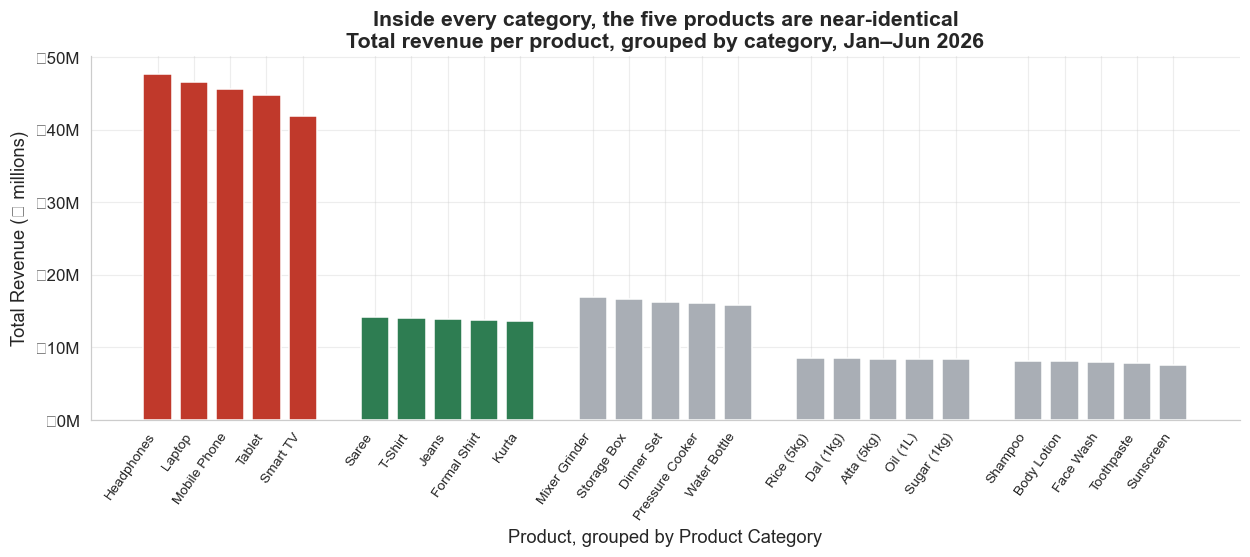

In [19]:
# Visual confirmation: within a category the five products sit almost on top of each other.
fig, ax = plt.subplots(figsize=(11.5, 5.2))

x_pos, x_labels, colours, vals, pos = [], [], [], [], 0
for cat in CAT_ORDER:
    s = prod[prod.category == cat].sort_values("revenue", ascending=False)
    for _, r in s.iterrows():
        x_pos.append(pos); x_labels.append(r.product_name)
        colours.append(CAT_COLOURS[cat]); vals.append(r.revenue / 1e6); pos += 1
    pos += 1                                            # gap between category blocks

ax.bar(x_pos, vals, color=colours, width=0.78)
ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels, rotation=55, ha="right", fontsize=9)
ax.set_title("Inside every category, the five products are near-identical\n"
             "Total revenue per product, grouped by category, Jan\u2013Jun 2026")
ax.set_ylabel("Total Revenue (\u20b9 millions)")
ax.set_xlabel("Product, grouped by Product Category")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"\u20b9{v:.0f}M"))
tidy(ax)
plt.tight_layout()
plt.show()

**The "bottom 2 by revenue" question has a misleading answer here — and we should say so rather
than quietly work around it.**

Every category holds five products, and within each they are near-identical in total revenue. In
**Grocery the best beats the worst by 2.1%**; in Apparel 4.0%; even Electronics only 13.9%. There
are no dead products dragging a category down. Ranking by six-month total sorts near-ties — and
**challenging a supplier over a 2% gap would not survive thirty seconds of pushback.**

> **This is the trap worth naming.** Following the instruction literally, the "weakest" Electronics
> product is **Smart TV** at ₹41.88M. But Smart TV fell only 21.9%, while **Mobile Phone fell 57.1%**
> — and Mobile Phone never appears in a bottom-two screen because it ranks *third* by revenue.
> Challenging the supplier on Smart TV would target the wrong product with the wrong number.

**The real differentiation is direction, not level.**

In [20]:
prod_month = df.pivot_table(index="product_name", columns="month",
                            values="revenue", aggfunc="sum")

trend = pd.DataFrame({
    "Product Category":     df.groupby("product_name").category.first(),
    "Total Revenue (\u20b9M)":  (prod_month.sum(axis=1) / 1e6).round(2),
    "Jan (\u20b9M)":            (prod_month.iloc[:, 0]  / 1e6).round(2),
    "Jun (\u20b9M)":            (prod_month.iloc[:, -1] / 1e6).round(2),
    "Change Jan\u2192Jun (%)":  ((prod_month.iloc[:, -1] / prod_month.iloc[:, 0] - 1) * 100).round(1),
}).sort_values("Change Jan\u2192Jun (%)")
trend.index.name = "Product"

elec = prod[prod.category == "Electronics"].sort_values("revenue", ascending=False)
rank = list(elec.product_name).index("Mobile Phone") + 1
print(f"Mobile Phone ranks {rank} of {len(elec)} in Electronics by total revenue "
      f"-> invisible to a 'bottom 2' screen.")
print(f"Yet it is the worst-declining product in the chain at "
      f"{trend.loc['Mobile Phone', 'Change Jan\u2192Jun (%)']:+.1f}%.")
print()
trend

Mobile Phone ranks 3 of 5 in Electronics by total revenue -> invisible to a 'bottom 2' screen.
Yet it is the worst-declining product in the chain at -57.1%.



,Product Category,Total Revenue (₹M),Jan (₹M),Jun (₹M),Change Jan→Jun (%)
Product,,,,,
Mobile Phone,Electronics,45.65,9.80,4.21,-57.1
Tablet,Electronics,44.74,9.76,5.76,-40.9
Laptop,Electronics,46.55,9.49,6.58,-30.7
Dinner Set,Home & Kitchen,16.30,3.03,2.20,-27.2
Smart TV,Electronics,41.88,7.53,5.88,-21.9
Mixer Grinder,Home & Kitchen,16.90,3.03,2.37,-21.9
Water Bottle,Home & Kitchen,15.83,3.06,2.43,-20.3
Headphones,Electronics,47.70,9.10,7.25,-20.3
Pressure Cooker,Home & Kitchen,16.14,2.91,2.57,-11.7


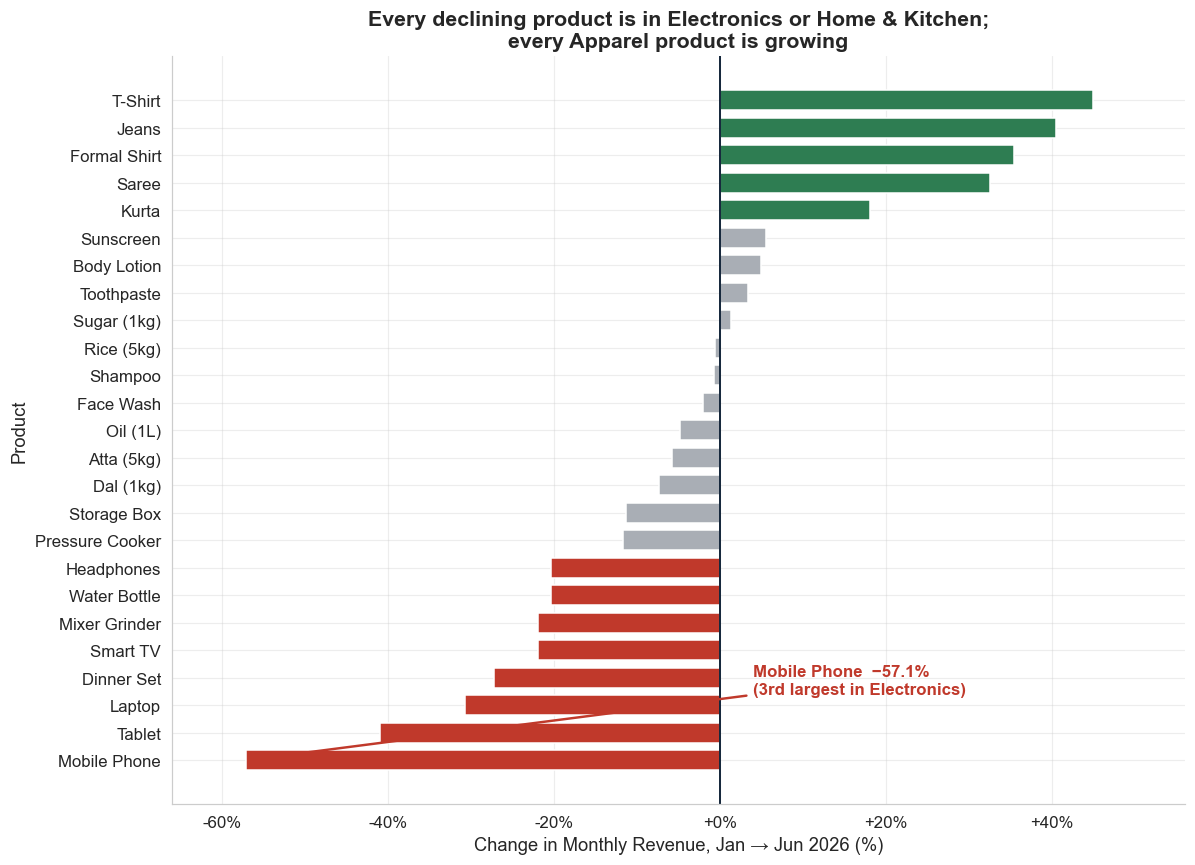

In [21]:
fig, ax = plt.subplots(figsize=(11, 8))

bar_colours = [RED if v < -15 else (GREEN if v > 10 else GREY)
               for v in trend["Change Jan\u2192Jun (%)"]]
ax.barh(trend.index, trend["Change Jan\u2192Jun (%)"], color=bar_colours, height=0.72)
ax.axvline(0, color=NAVY, linewidth=1.3)

ax.annotate("Mobile Phone  \u221257.1%\n(3rd largest in Electronics)",
            xy=(-57.1, 0), xytext=(4, 2.4), fontsize=11, color=RED, fontweight="bold",
            arrowprops=dict(arrowstyle="->", color=RED, lw=1.6))
ax.set_xlim(-66, 56)

ax.set_title("Every declining product is in Electronics or Home & Kitchen;\n"
             "every Apparel product is growing")
ax.set_xlabel("Change in Monthly Revenue, Jan \u2192 Jun 2026 (%)")
ax.set_ylabel("Product")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:+.0f}%"))
tidy(ax, grid_axis="x")
plt.tight_layout()
plt.show()

### Which supplier we would challenge, and why

**The Electronics supplier — specifically on the Mobile Phone line.**

Mobile Phone fell **57.1%**, the worst result of any product in the chain. Because *all five*
Electronics products declined, this is not one weak SKU inside a healthy range — it is a
category-wide collapse, which points at the **supplier relationship** rather than a product life
cycle. When an entire category moves together, the explanation usually sits with the supplier, the
range or the pricing, not with consumer taste changing on five separate products at once. Apparel is
the mirror image and reinforces the point.

**The finding to state carefully:** Mobile Phone carries **₹45.65M** in six-month revenue — the
**third-largest product in Electronics**. A bottom-two-by-revenue screen ranks it 3rd of 5 and passes
straight over it. *The chain's fastest-collapsing product is hiding inside its top half.*

**The challenge, with Step 2's diagnosis attached:** their category has lost **₹16.0M of monthly
run-rate** while holding 49.3% of chain revenue, and the cause is **33.4% fewer transactions**, not
our pricing — which moved only 2.2%. So the question is not "should we discount more"; it is what
changed in their competitive position on mobile phones, and what they are committing to fix it.

**Home & Kitchen deserves the second conversation.** Dinner Set (−27.2%) and Mixer Grinder (−21.9%)
are falling nearly as fast as mid-range Electronics products. Small enough to overlook — which is
why it should be raised now.

---

---
# Step 4 — Discount effectiveness analysis

*Section owner: [Member 3 Name]*

> **The question:** does a discount buy enough extra volume to pay for the price it gives up?

This is a stricter question than "do discounted transactions look different?" A discount only works
if customers **buy more because of it**. So the test compares behaviour *within* brackets — and then
checks whether any apparent difference is real or just noise.

In [22]:
disc = df.groupby("discount_pct").agg(
    transactions         =("transaction_id",   "count"),
    avg_revenue_per_txn  =("revenue",          "mean"),
    avg_units_per_txn    =("units_sold",       "mean"),
    avg_gross_per_txn    =("gross_revenue",    "mean"),
    total_discount_given =("discount_amount",  "sum"),
)

# Show ALL SIX brackets the brief names, so the empty one is demonstrated, not omitted.
disc_all = disc.reindex([0, 5, 10, 15, 20, 25])
disc_all.index = ["0%", "5%", "10%", "15%", "20%", "25%+"]
disc_all.index.name = "Discount Bracket"
disc_all["transactions"] = disc_all["transactions"].fillna(0).astype(int)

print("All six brackets named in the brief. The sixth has no transactions.")
disc_all.round(1)

All six brackets named in the brief. The sixth has no transactions.


,transactions,avg_revenue_per_txn,avg_units_per_txn,avg_gross_per_txn,total_discount_given
Discount Bracket,,,,,
0%,36033,4685.7,2.6,4685.7,0.0
5%,23922,4303.7,2.6,4530.2,5418627.2
10%,23810,4005.5,2.6,4450.6,10596890.3
15%,11935,4069.2,2.6,4787.3,8570379.5
20%,12136,3631.7,2.6,4539.7,11018660.7
25%+,0,NaN,NaN,NaN,NaN


In [23]:
# ---- Is the apparent flatness real, or could it be noise? ------------------------
#
# A 95% confidence interval says: given this sample, the TRUE average almost certainly
# lies inside this range. If the top of the range is still ~flat, we can RULE OUT a lift
# rather than merely fail to find one - a much stronger statement.

ci = df.groupby("discount_pct").units_sold.agg(["mean", "std", "count"])
ci["std_error"] = ci["std"] / np.sqrt(ci["count"])
ci["ci_low"]    = ci["mean"] - 1.96 * ci["std_error"]
ci["ci_high"]   = ci["mean"] + 1.96 * ci["std_error"]

baseline = ci.loc[0, "mean"]
ci["max_possible_lift_%"] = (ci["ci_high"] - baseline) / baseline * 100

out = ci[["count", "mean", "ci_low", "ci_high", "max_possible_lift_%"]].round(4)
out.index = [f"{i}%" for i in out.index]
out.index.name = "Discount Bracket"
out.columns = ["Transactions", "Avg Units/Txn", "95% CI Low", "95% CI High",
               "Max Possible Lift (%)"]

print("BREAK-EVEN TEST")
for d in [5, 10, 15, 20]:
    need = (1 / (1 - d/100) - 1) * 100
    got  = ci.loc[d, "max_possible_lift_%"]
    print(f"  A {d:>2}% discount needs +{need:>5.1f}% units just to hold revenue flat. "
          f"Upper bound of what it actually delivers: {got:+.2f}%")
print()
out

BREAK-EVEN TEST
  A  5% discount needs +  5.3% units just to hold revenue flat. Upper bound of what it actually delivers: +0.95%
  A 10% discount needs + 11.1% units just to hold revenue flat. Upper bound of what it actually delivers: -0.04%
  A 15% discount needs + 17.6% units just to hold revenue flat. Upper bound of what it actually delivers: +1.37%
  A 20% discount needs + 25.0% units just to hold revenue flat. Upper bound of what it actually delivers: +0.84%



,Transactions,Avg Units/Txn,95% CI Low,95% CI High,Max Possible Lift (%)
Discount Bracket,,,,,
0%,36033,2.5860,2.5708,2.6013,0.5896
5%,23922,2.5919,2.5732,2.6106,0.9492
10%,23810,2.5664,2.5478,2.5850,-0.0390
15%,11935,2.5951,2.5688,2.6214,1.3700
20%,12136,2.5815,2.5553,2.6076,0.8362


/var/folders/xx/r16ts3p97xqdv0vbjmfc4fmh0000gn/T/ipykernel_41301/3411517155.py:41: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


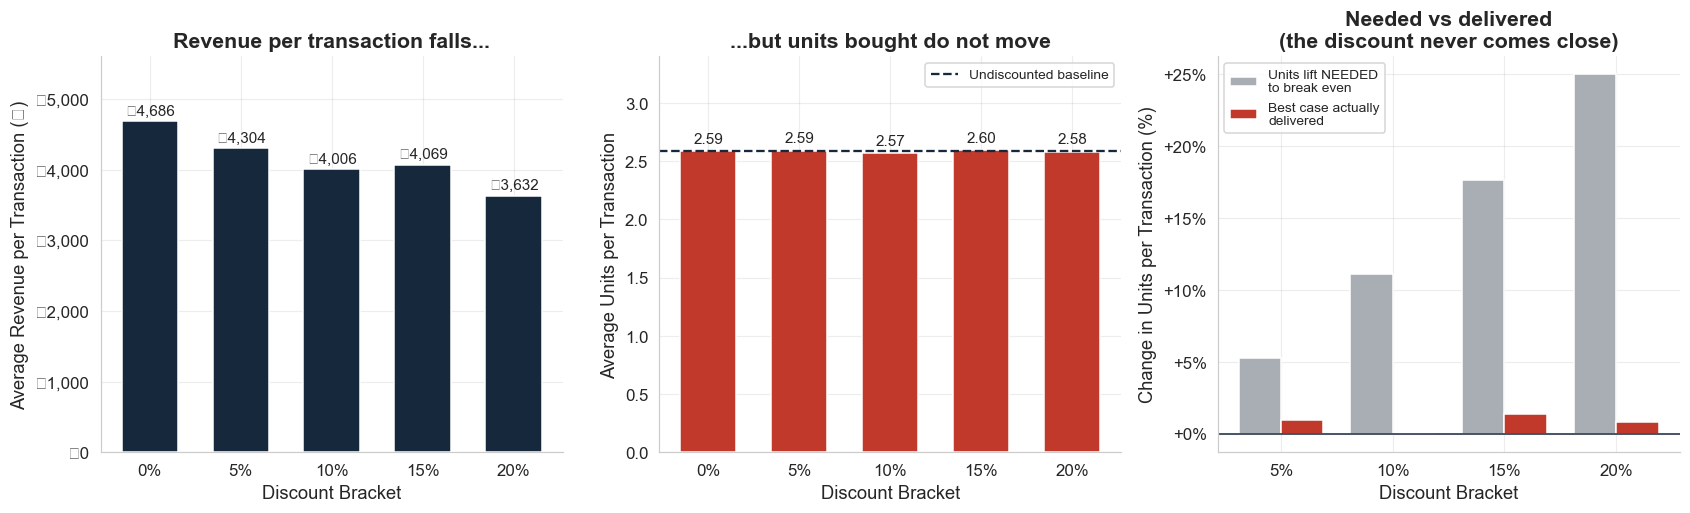

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.8))
labels = [f"{i}%" for i in disc.index]

# REQUIRED CHART: average revenue per transaction by discount bracket
axes[0].bar(labels, disc.avg_revenue_per_txn, color=NAVY, width=0.62)
axes[0].set_title("Revenue per transaction falls...")
axes[0].set_ylabel("Average Revenue per Transaction (\u20b9)")
axes[0].set_ylim(0, 5600)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"\u20b9{v:,.0f}"))
for i, v in enumerate(disc.avg_revenue_per_txn):
    axes[0].text(i, v + 90, f"\u20b9{v:,.0f}", ha="center", fontsize=10)

# THE CONTROL: do customers actually buy more?
axes[1].bar(labels, disc.avg_units_per_txn, color=RED, width=0.62)
axes[1].axhline(disc.avg_units_per_txn.iloc[0], color=NAVY, linestyle="--", linewidth=1.5,
                label="Undiscounted baseline")
axes[1].set_title("...but units bought do not move")
axes[1].set_ylabel("Average Units per Transaction")
axes[1].set_ylim(0, 3.4)
axes[1].legend(frameon=True, loc="upper right", fontsize=9)
for i, v in enumerate(disc.avg_units_per_txn):
    axes[1].text(i, v + 0.07, f"{v:.2f}", ha="center", fontsize=10)

# WHAT WOULD BE NEEDED vs WHAT IS DELIVERED
# The 0% bracket is the baseline itself, so it is excluded here.
brackets = [d for d in disc.index if d > 0]
need = [(1/(1 - d/100) - 1) * 100 for d in brackets]
got  = [ci.loc[d, "max_possible_lift_%"] for d in brackets]
x = np.arange(len(brackets))
axes[2].bar(x - 0.19, need, 0.38, color=GREY,  label="Units lift NEEDED\nto break even")
axes[2].bar(x + 0.19, got,  0.38, color=RED,   label="Best case actually\ndelivered")
axes[2].set_xticks(x); axes[2].set_xticklabels([f"{d}%" for d in brackets])
axes[2].set_title("Needed vs delivered\n(the discount never comes close)")
axes[2].set_ylabel("Change in Units per Transaction (%)")
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:+.0f}%"))
axes[2].legend(frameon=True, fontsize=9)
axes[2].axhline(0, color=NAVY, linewidth=1)

for a in axes:
    a.set_xlabel("Discount Bracket"); tidy(a)
plt.tight_layout()
plt.show()

In [25]:
# ---- Robustness: does discounting work in ANY single category? -------------------
cat_lift = df.pivot_table(index="category", columns="discount_pct",
                          values="units_sold", aggfunc="mean").reindex(CAT_ORDER)
cat_lift = (cat_lift.div(cat_lift[0], axis=0) * 100).round(1)
cat_lift.columns = [f"{c}%" for c in cat_lift.columns]
cat_lift.index.name = "Product Category"

print("Units per transaction, indexed to each category's own 0% bracket (100 = no lift)")
print("Not one category reaches even +3%.")
print()
cat_lift

Units per transaction, indexed to each category's own 0% bracket (100 = no lift)
Not one category reaches even +3%.



,0%,5%,10%,15%,20%
Product Category,,,,,
Electronics,100.0,100.5,99.9,102.8,102.4
Apparel,100.0,100.0,97.3,100.5,99.5
Home & Kitchen,100.0,100.6,98.8,101.3,101.7
Grocery,100.0,100.5,99.4,100.2,99.5
Personal Care,100.0,99.6,100.1,99.9,99.7


In [26]:
# ---- Is the chain discounting harder as revenue falls? ---------------------------
depth = df.groupby("month").agg(avg_discount=("discount_pct", "mean"),
                                pct_discounted=("discount_pct", lambda s: (s > 0).mean() * 100))
depth.index = MONTH_ORDER

print("Discount depth over time - stable, so the decline is NOT the chain chasing")
print("a falling market with deeper cuts:")
print(depth.round(2).to_string())
print()

total_gross, total_net = df.gross_revenue.sum(), df.revenue.sum()
total_discount = df.discount_amount.sum()
print("THE PRICE OF THE PROGRAMME, JAN-JUN 2026")
print(f"  Gross revenue before discount   : \u20b9{total_gross/1e6:>8,.1f}M")
print(f"  Net revenue realised            : \u20b9{total_net/1e6:>8,.1f}M")
print(f"  Margin given away as discount   : \u20b9{total_discount/1e6:>8,.1f}M  "
      f"({total_discount/total_gross*100:.1f}% of gross)")
print(f"  Transactions carrying a discount: {(df.discount_pct > 0).mean()*100:>7.1f}%")

Discount depth over time - stable, so the decline is NOT the chain chasing
a falling market with deeper cuts:
     avg_discount  pct_discounted
Jan          7.24           66.50
Feb          7.37           67.16
Mar          7.26           66.86
Apr          7.21           66.60
May          7.11           65.84
Jun          7.20           66.63

THE PRICE OF THE PROGRAMME, JAN-JUN 2026
  Gross revenue before discount   : ₹   495.4M
  Net revenue realised            : ₹   459.8M
  Margin given away as discount   : ₹    35.6M  (7.2% of gross)
  Transactions carrying a discount:    66.6%


### Our position: the discount programme is not working, and we can prove it is not noise

**The discounts buy nothing.** Average units per transaction is **2.586 at 0% discount and 2.582 at
20%**. Across 107,836 transactions there is no volume response at any depth.

**And this is a genuine null, not a failure to detect.** With samples this large the confidence
intervals are tight: **the upper bound of any bracket's possible lift is +1.37%**, and for the 20%
bracket it is **+0.84%**. So we are not saying "we found no effect" — we are saying **we can rule
out any effect larger than about 1%.**

**Set that against what a discount needs to earn.** A 20% discount must generate **+25% units** just
to hold revenue flat. The best case the data permits is **+0.84%** — about **3% of what is required**.
Every bracket fails the same test by a similar margin.

**It fails in every category too.** Indexed to each category's own undiscounted baseline, no
category reaches even +3% at any depth. There is no hidden pocket where discounting works.

**The confirming test.** Average *gross* value per transaction is also flat across brackets (₹4,686
at 0%, ₹4,540 at 20%) — discounts are not even landing on larger baskets. So the fall in net revenue
per transaction, **₹4,686 → ₹3,632 (−22.5%)**, is close to pure price transfer.

**What it cost.** **₹35.6M** over six months, **7.2% of gross revenue**, across **66.6% of all
transactions**. On this evidence the great majority went to customers who would have bought the same
quantity at full price.

### What she should raise with suppliers

Treat promotional investment as **unproven spend rather than a given**. Any supplier requesting
continued support commits to a measurable volume target, and the chain runs a controlled test —
holding discounts at 0% across a matched set of stores for one cycle — before renewing at current
depth.

### Two caveats to carry into the meeting

**We cannot speak to margin.** The dataset has `unit_price` but **no product cost**, so margin cannot
be computed at all. We can say ₹35.6M of revenue was given away with no volume response; we cannot
say what that did to profit, and we should not let the phrase "margin erosion" into the room
unqualified.

**This describes a blanket programme.** Discount depth is near-identical across all five categories
and stable month to month, so we cannot separate a discount effect from a category effect. The
finding holds as stated — no lift anywhere — but a well-targeted campaign might behave differently.

> **A trap worth naming.** It is tempting to read the falling transaction counts (36,033 at 0% vs
> 12,136 at 20%) as "customers avoid discounted items". They do not. That column counts how often
> *the retailer chose* to apply each discount — a policy decision, not a customer reaction.

---

---
# Step 5 — Day-of-week and monthly patterns

*Section owner: [Member 4 Name]*

> **The question:** when is demand naturally strong, and when are we promoting into an empty shop?

One methodological note. "Average daily revenue by day" means: total revenue for each **calendar
date**, then average those daily totals within each weekday. Averaging transaction-level revenue
instead gives **average basket size** — a different question with a different answer.

/var/folders/xx/r16ts3p97xqdv0vbjmfc4fmh0000gn/T/ipykernel_41301/2081225087.py:31: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


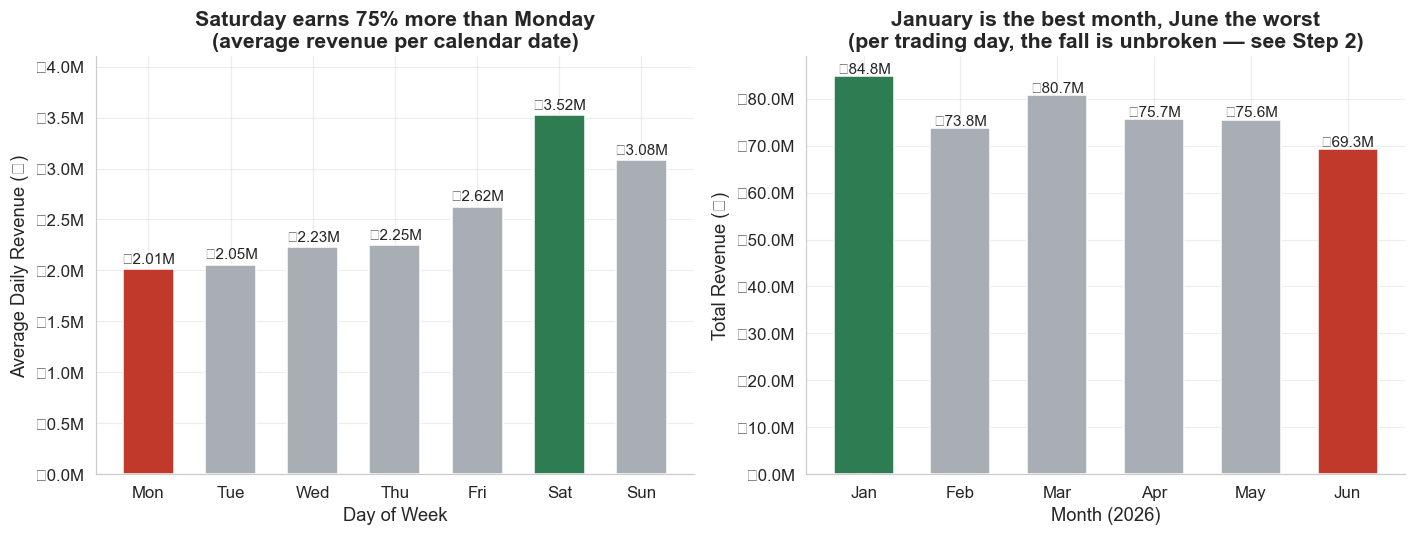

CHAIN OVERALL
  Best day    : Saturday   ₹3.52M average
  Worst day   : Monday     ₹2.01M average   (+75.1% Saturday vs Monday)
  Best month  : Jan        ₹84.8M
  Worst month : Jun        ₹69.3M


In [27]:
daily   = df.groupby("date").revenue.sum()
dow_avg = daily.groupby(daily.index.day_name()).mean().reindex(DOW_ORDER)
monthly = df.groupby("month").revenue.sum(); monthly.index = MONTH_ORDER

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bar_colours = [GREY] * 7
bar_colours[DOW_ORDER.index(dow_avg.idxmax())] = GREEN
bar_colours[DOW_ORDER.index(dow_avg.idxmin())] = RED
axes[0].bar([d[:3] for d in DOW_ORDER], dow_avg.values, color=bar_colours, width=0.62)
axes[0].set_title("Saturday earns 75% more than Monday\n(average revenue per calendar date)")
axes[0].set_xlabel("Day of Week")
axes[0].set_ylabel("Average Daily Revenue (\u20b9)")
axes[0].set_ylim(0, 4.1e6)
for i, v in enumerate(dow_avg.values):
    axes[0].text(i, v + 6e4, f"\u20b9{v/1e6:.2f}M", ha="center", fontsize=10)

m_colours = [GREY] * 6
m_colours[list(monthly).index(monthly.max())] = GREEN
m_colours[list(monthly).index(monthly.min())] = RED
axes[1].bar(monthly.index, monthly.values, color=m_colours, width=0.62)
axes[1].set_title("January is the best month, June the worst\n"
                  "(per trading day, the fall is unbroken \u2014 see Step 2)")
axes[1].set_xlabel("Month (2026)")
axes[1].set_ylabel("Total Revenue (\u20b9)")
for i, v in enumerate(monthly.values):
    axes[1].text(i, v + 6e5, f"\u20b9{v/1e6:.1f}M", ha="center", fontsize=10)

for a in axes:
    rupees(a, dp=1); tidy(a)
plt.tight_layout()
plt.show()

print("CHAIN OVERALL")
print(f"  Best day    : {dow_avg.idxmax():<10} \u20b9{dow_avg.max()/1e6:.2f}M average")
print(f"  Worst day   : {dow_avg.idxmin():<10} \u20b9{dow_avg.min()/1e6:.2f}M average"
      f"   ({(dow_avg.max()/dow_avg.min()-1)*100:+.1f}% Saturday vs Monday)")
print(f"  Best month  : {monthly.idxmax():<10} \u20b9{monthly.max()/1e6:.1f}M")
print(f"  Worst month : {monthly.idxmin():<10} \u20b9{monthly.min()/1e6:.1f}M")

In [28]:
# ---- The single most interesting category from Step 2 ----------------------------
FOCUS = "Electronics"          # 49.3% of the chain, and the category driving the decline
sub = df[df.category == FOCUS]

f_daily   = sub.groupby("date").revenue.sum()
f_dow     = f_daily.groupby(f_daily.index.day_name()).mean().reindex(DOW_ORDER)
f_monthly = sub.groupby("month").revenue.sum(); f_monthly.index = MONTH_ORDER

print(f"{FOCUS.upper()} ONLY")
print(f"  Best day    : {f_dow.idxmax():<10} \u20b9{f_dow.max()/1e6:.2f}M average")
print(f"  Worst day   : {f_dow.idxmin():<10} \u20b9{f_dow.min()/1e6:.2f}M average")
print(f"  Best month  : {f_monthly.idxmax():<10} \u20b9{f_monthly.max()/1e6:.1f}M")
print(f"  Worst month : {f_monthly.idxmin():<10} \u20b9{f_monthly.min()/1e6:.1f}M")
print()
same_day   = f_dow.idxmax() == dow_avg.idxmax() and f_dow.idxmin() == dow_avg.idxmin()
same_month = f_monthly.idxmax() == monthly.idxmax() and f_monthly.idxmin() == monthly.idxmin()
print(f"  Same best/worst DAY as the chain?   {'YES' if same_day else 'NO'}")
print(f"  Same best/worst MONTH as the chain? {'YES' if same_month else 'NO'}")
print()
print("  The DIRECTION matches. The AMPLITUDE does not - indexed below.")

ELECTRONICS ONLY
  Best day    : Saturday   ₹1.79M average
  Worst day   : Monday     ₹0.97M average
  Best month  : Jan        ₹45.7M
  Worst month : Jun        ₹29.7M

  Same best/worst DAY as the chain?   YES
  Same best/worst MONTH as the chain? YES

  The DIRECTION matches. The AMPLITUDE does not - indexed below.


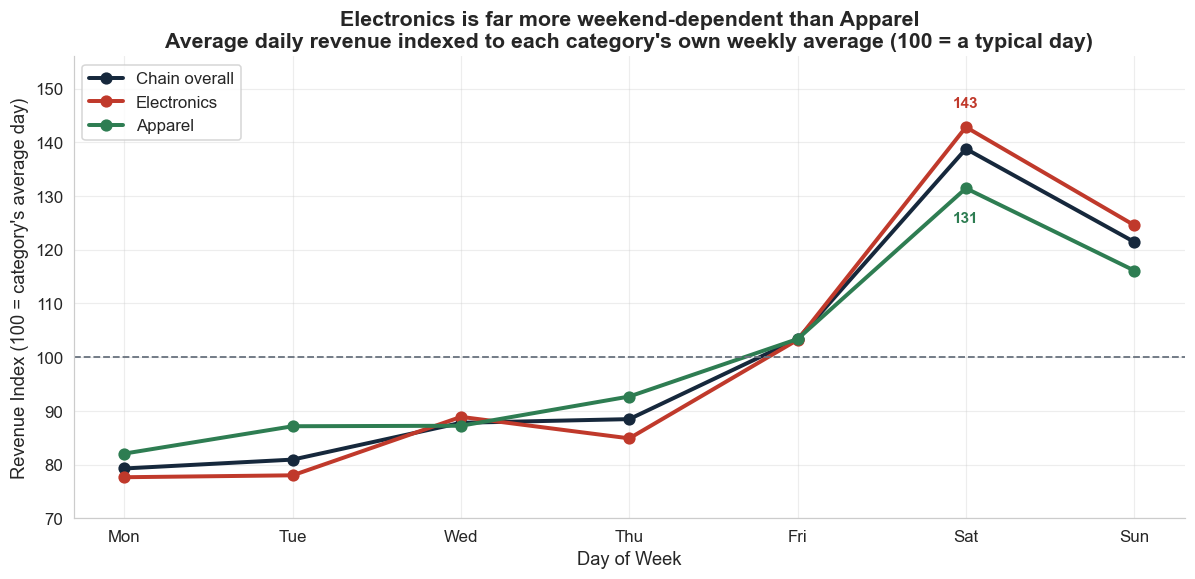

In [29]:
# Indexing each category to its OWN weekly average lets us compare the SHAPE of the
# week across categories of very different sizes.
fig, ax = plt.subplots(figsize=(11, 5.4))

chain_idx = dow_avg / dow_avg.mean() * 100
ax.plot([d[:3] for d in DOW_ORDER], chain_idx, marker="o", markersize=7,
        linewidth=2.6, color=NAVY, label="Chain overall")

for cat in ["Electronics", "Apparel"]:
    s   = df[df.category == cat].groupby("date").revenue.sum()
    idx = s.groupby(s.index.day_name()).mean().reindex(DOW_ORDER)
    idx = idx / idx.mean() * 100
    ax.plot([d[:3] for d in DOW_ORDER], idx, marker="o", markersize=7,
            linewidth=2.6, color=CAT_COLOURS[cat], label=cat)
    nudge = 13 if cat == "Electronics" else -22
    ax.annotate(f"{idx['Saturday']:.0f}", xy=(5, idx["Saturday"]), xytext=(0, nudge),
                textcoords="offset points", ha="center", fontsize=10,
                color=CAT_COLOURS[cat], fontweight="bold")

ax.axhline(100, color=MUTED, linestyle="--", linewidth=1.2)
ax.set_title("Electronics is far more weekend-dependent than Apparel\n"
             "Average daily revenue indexed to each category's own weekly average "
             "(100 = a typical day)")
ax.set_xlabel("Day of Week")
ax.set_ylabel("Revenue Index (100 = category's average day)")
ax.set_ylim(70, 156)
ax.legend(frameon=True, loc="upper left")
tidy(ax)
plt.tight_layout()
plt.show()

### What we found — Step 5

**Chain overall:** best day **Saturday** (₹3.52M average), worst day **Monday** (₹2.01M) — Saturday
earns **75.1% more**. Best month **January** (₹84.8M), worst **June** (₹69.3M).

**Electronics shares the chain's best and worst day and month, but not its amplitude.** Indexed to
its own average day, Electronics runs at **142.8 on Saturday and 77.6 on Monday** — a 65-point swing.
Apparel is visibly flatter at **131.5 and 82.0**. So Electronics follows the same *pattern* while
being markedly **more extreme**.

### What this means for promotional timing

A high-consideration purchase like a laptop or phone needs an unhurried visit, so Electronics demand
concentrates into the weekend, while Apparel picks up incidental weekday footfall. **Promotional
spend should be concentrated Friday to Sunday**, when customers are already in store and in a buying
posture, and pulled out of Monday and Tuesday, where no category shows latent demand to unlock. That
holds especially for Electronics — the category we most need to revive is also the one whose
customers are **least available midweek**, so midweek Electronics promotion spends against the grain
of the traffic.

**One honest qualification.** Concentrating promotions on Saturday is *demand capture*, not *demand
generation* — we would be discounting customers who were already coming. Given Step 2's finding that
the problem is **33.4% fewer transactions**, the real need is to bring people back, and Step 4 shows
discount depth will not do that. Weekend timing is the cheaper lever; it is not the cure.

---

---
# Additional analysis — geography and robustness

*Not required by the brief. Included because it tests whether the Electronics finding survives the
supplier's most likely counter-argument.*

The dataset carries `store_id` and `store_city`, which the six required steps never touch. If the
Electronics decline were concentrated in two or three stores, it would be an execution problem — ours
to fix, not the supplier's. We should know the answer before the supplier asks the question.

In [30]:
city = df.groupby("store_city").agg(revenue=("revenue", "sum"),
                                    stores=("store_id", "nunique"))
city["revenue_per_store"] = city.revenue / city.stores
city = city.sort_values("revenue", ascending=False)

elec_by_city = (df[df.category == "Electronics"]
                .pivot_table(index="store_city", columns="month", values="revenue", aggfunc="sum"))
city["electronics_change_pct"] = ((elec_by_city.iloc[:, -1] / elec_by_city.iloc[:, 0] - 1) * 100).round(1)

summary_city = pd.DataFrame({
    "Stores":                  city.stores,
    "Total Revenue (\u20b9M)":     (city.revenue / 1e6).round(1),
    "Revenue per Store (\u20b9M)": (city.revenue_per_store / 1e6).round(1),
    "Electronics Jan\u2192Jun (%)": city.electronics_change_pct,
})
summary_city.index.name = "Store City"
summary_city

,Stores,Total Revenue (₹M),Revenue per Store (₹M),Electronics Jan→Jun (%)
Store City,,,,
Vijayawada,2,101.1,50.6,-37.1
Guntur,2,94.6,47.3,-44.9
Tirupati,2,83.6,41.8,-44.2
Rajahmundry,2,70.1,35.1,-27.1
Nellore,2,55.7,27.8,-25.3
Kakinada,2,54.8,27.4,-14.7


/var/folders/xx/r16ts3p97xqdv0vbjmfc4fmh0000gn/T/ipykernel_41301/2691404129.py:27: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


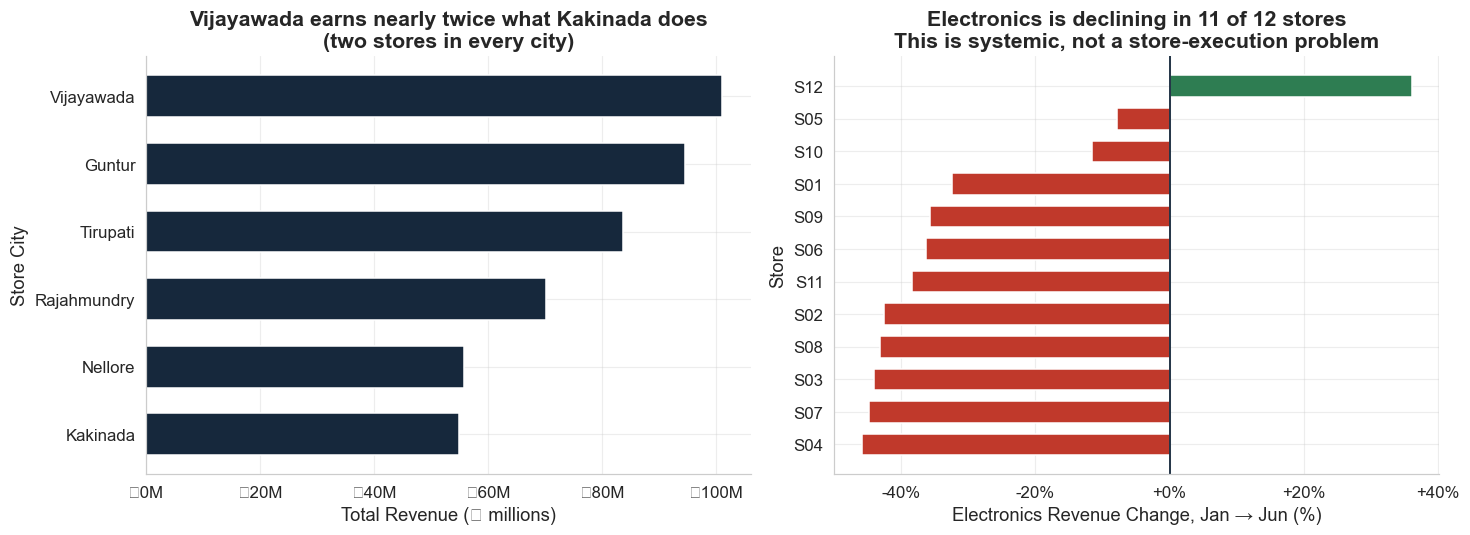

Stores with Electronics declining : 11 of 12
Range across stores               : -45.9% to +36.1%


In [31]:
# Is the Electronics decline everywhere, or concentrated in a few stores?
elec_store = (df[df.category == "Electronics"]
              .pivot_table(index="store_id", columns="month", values="revenue", aggfunc="sum"))
store_change = ((elec_store.iloc[:, -1] / elec_store.iloc[:, 0] - 1) * 100).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5))

axes[0].barh(summary_city.index, summary_city["Total Revenue (\u20b9M)"], color=NAVY, height=0.62)
axes[0].set_title("Vijayawada earns nearly twice what Kakinada does\n"
                  "(two stores in every city)")
axes[0].set_xlabel("Total Revenue (\u20b9 millions)")
axes[0].set_ylabel("Store City")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"\u20b9{v:.0f}M"))
axes[0].invert_yaxis()
tidy(axes[0], grid_axis="x")

axes[1].barh(store_change.index, store_change.values,
             color=[RED if v < 0 else GREEN for v in store_change.values], height=0.66)
axes[1].axvline(0, color=NAVY, linewidth=1.2)
axes[1].set_title(f"Electronics is declining in {(store_change < 0).sum()} of "
                  f"{len(store_change)} stores\nThis is systemic, not a store-execution problem")
axes[1].set_xlabel("Electronics Revenue Change, Jan \u2192 Jun (%)")
axes[1].set_ylabel("Store")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:+.0f}%"))
tidy(axes[1], grid_axis="x")

plt.tight_layout()
plt.show()

print(f"Stores with Electronics declining : {(store_change < 0).sum()} of {len(store_change)}")
print(f"Range across stores               : {store_change.min():+.1f}% to {store_change.max():+.1f}%")

In [32]:
# Do the cities differ in what they sell, or only in how much?
mix = pd.crosstab(df.store_city, df.category,
                  values=df.revenue, aggfunc="sum", normalize="index") * 100
mix = mix.reindex(columns=CAT_ORDER).round(1)
mix.index.name = "Store City"

print("Category mix by city (% of that city's revenue)")
print("Near-identical rows: cities differ in SIZE, not in what they buy.")
print()
mix

Category mix by city (% of that city's revenue)
Near-identical rows: cities differ in SIZE, not in what they buy.



category,Electronics,Apparel,Home & Kitchen,Grocery,Personal Care
Store City,,,,,
Guntur,49.8,14.9,17.8,8.9,8.6
Kakinada,51.0,14.7,16.8,9.2,8.4
Nellore,46.6,15.8,18.3,10.0,9.3
Rajahmundry,49.9,14.7,17.6,9.3,8.5
Tirupati,48.5,15.4,18.1,9.3,8.8
Vijayawada,49.5,15.2,17.9,8.9,8.4


### What we found — geography

**The Electronics decline is systemic. It is falling in 11 of 12 stores**, across every one of the
six cities, ranging from −14.7% in Kakinada to −44.9% in Guntur. That closes off the supplier's most
convenient defence — this is not two weak stores or one bad manager, and it cannot be answered with
"your Guntur team stopped merchandising us properly."

**Cities differ in scale, not in taste.** Vijayawada turns over ₹101.1M against Kakinada's ₹54.8M —
nearly double, from the same two-store footprint. But the category mix is almost identical
everywhere (Electronics runs 46.6%–51.0% of revenue in every city). So the gap is catchment and
footfall, not different shopping behaviour, and a category-level decision applies uniformly across
the estate.

**Why this belongs in the supplier meeting.** Combined with Step 2, the Electronics story is now
fully specified: revenue down 35%, driven by 33.4% fewer transactions, with prices held within 2.2%,
happening in 11 of 12 stores simultaneously. That is not a chain execution failure. It is a demand
problem the supplier owns.

---

---
# Step 6 — Category Manager Briefing



> What we would actually say to the Category Manager as she walks into the supplier review.

## Category Manager Briefing

**Apparel has the strongest case for increased investment.** It grew **34.1%**, from ₹10.1M to
₹13.5M in monthly revenue, and it is the only category where **all five products grew** — T-Shirt
+44.9%, Jeans +40.5%, Saree +32.6%. Critically, that growth came from **31.3% more transactions**
with average price flat — real new demand, not a pricing artefact. In a chain where revenue per
trading day fell 15.5%, Apparel is the only place money is being added, and it is earning more shelf
space than it holds.

**Challenge the Electronics supplier, on Mobile Phone specifically, and lead with the diagnosis.**
Electronics fell **35.0%**, from **₹45.7M to ₹29.7M** monthly — **₹16.0M of lost run-rate** from a
category that is 49.3% of the chain. Within it, **Mobile Phone dropped 57.1%**, the steepest fall of
any product we sell, while carrying **₹45.65M** in revenue and ranking third of five — a
bottom-two-by-revenue screen would have missed it entirely. And the cause is not ours: transactions
fell 33.4% while our average price moved only 2.2%, in **11 of 12 stores**. Roughly a third fewer
customers are buying their category at all. Their size is the reason to act, not a defence against
acting.

**On discounts, raise this:** we gave away **₹35.6M** of revenue over six months, on **66.6%** of
transactions, and average units per transaction is **2.58 whether the discount is 0% or 20%**. This
is not a weak signal — the confidence intervals let us **rule out any volume lift above about 1%**,
against the **25%** a 20% discount needs just to break even. I would not renew promotional support at
current levels without a committed volume target, and I would hold a matched set of stores at 0% for
one cycle to prove the point.

**The one thing I want before a final call is cost and margin data per product.** Everything here is
revenue. I can tell you what is selling and what is not; I cannot tell you what is **profitable** —
the dataset has no cost column, so margin cannot be computed at all. It is possible the declining
Electronics line still contributes more gross margin per unit of shelf space than growing Apparel, in
which case we defend Electronics rather than reallocate away from it. I would also want competitor
pricing on the mobile range — a 57% fall driven by footfall rather than price usually means we were
undercut outside our stores.

---

# Limitations of this analysis

| Limitation | Consequence | What would resolve it |
| --- | --- | --- |
| **Revenue only — no cost or margin** | Every recommendation is a *revenue* recommendation. "Grow Apparel, challenge Electronics" is a well-evidenced hypothesis, not a proven allocation. The brief's phrase "eroding margin" cannot be answered at all from this file. | Cost or margin per product |
| **Six months is not a seasonal cycle** | Jan–Jun 2026 cannot distinguish a structural Electronics decline from post-festive normalisation. | A full year, or Jan–Jun 2025 to compare |
| **No customer identifier** | We cannot tell whether discounts attract new customers or subsidise existing ones — the likeliest explanation for the flat volume response. | Loyalty or customer ID per transaction |
| **Discount allocation is uniform and stable** | Depth is near-identical across categories and steady month to month, so Step 4 describes a *blanket* programme. It does not prove a targeted campaign would fail. | A controlled test: 0% on matched stores for one cycle |
| **No competitor or market data** | The decline is a footfall collapse with our prices held — consistent with being undercut, but this data cannot confirm it. | Competitor pricing on the mobile range |
| **No inventory or stock-out data** | A 33.4% transaction fall could partly reflect products being unavailable rather than unwanted. | Stock availability by store and SKU |

---